In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

In [3]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

In [4]:
def preprocess_runing(df):
    def convert(value):
        value = value.lower().replace(',', '').strip()
        if 'km' in value:
            return float(value.replace('km', '').strip())
        elif 'miles' in value:
            miles = float(value.replace('miles', '').strip())
            return round(miles * 1.60934, 2)
        return np.nan
    df['running'] = df['running'].apply(convert)
    return df

In [5]:
def car_age(df):
    df['car_age'] = 2023 - df['year'].astype(int)
    return df

In [6]:
def covert_to_float(df):
    df['motor_volume'] = pd.to_numeric(df['motor_volume'], errors='coerce')
    return df

In [7]:
def encode_categorical(df):
    encoders = {}
    lable_encoder = LabelEncoder()
    categorical_columns = ['model', 'motor_type', 'wheel', 'color', 'type', 'status']
    for column in categorical_columns:
        df[column] = lable_encoder.fit_transform(df[column].astype(str))
        encoders[column] = lable_encoder
    return df, encoders

In [8]:
train_df = preprocess_runing(train_df)
train_df = car_age(train_df)
train_df = covert_to_float(train_df)

train_df, encoders = encode_categorical(train_df)
train_df.dropna(inplace=True)


In [9]:
test_df = preprocess_runing(test_df)
test_df = car_age(test_df)      
test_df = covert_to_float(test_df)

for column, encoder in encoders.items():
    if column in test_df.columns:
        test_df[column] = test_df[column].map(lambda x: encoder.transform([x])[0] if x in encoder.classes_ else -1)

In [10]:
fecatures = ['model', 'motor_type', 'wheel', 'color', 'type', 'status', 'running', 'motor_volume', 'car_age']
target = 'price'
X_train = train_df[fecatures]
y_train = train_df[target]

In [11]:
rendom_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
rendom_forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
x_test = test_df[fecatures]
y_pred = rendom_forest_model.predict(x_test)


In [13]:
import os

os.makedirs('../outputs', exist_ok=True)

output_df = pd.DataFrame({
    'Id': x_test.index,
    'price': y_pred
})

output_df.to_csv('../outputs/predictions.csv', index=False)

In [14]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\chanuth_w\Desktop\Assignement\Car_price_prediction\backend\.venv\Scripts\python.exe
3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]


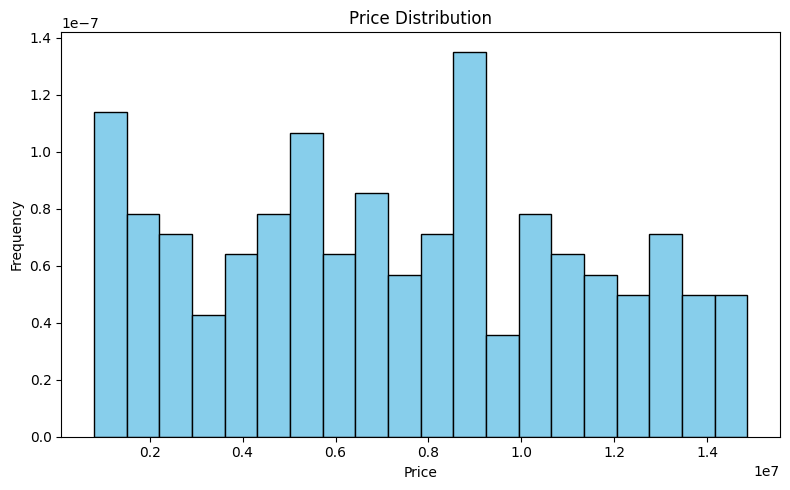

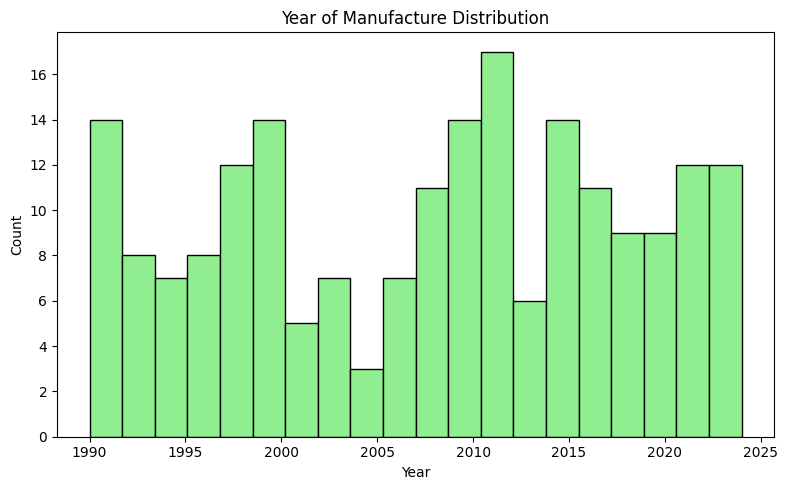

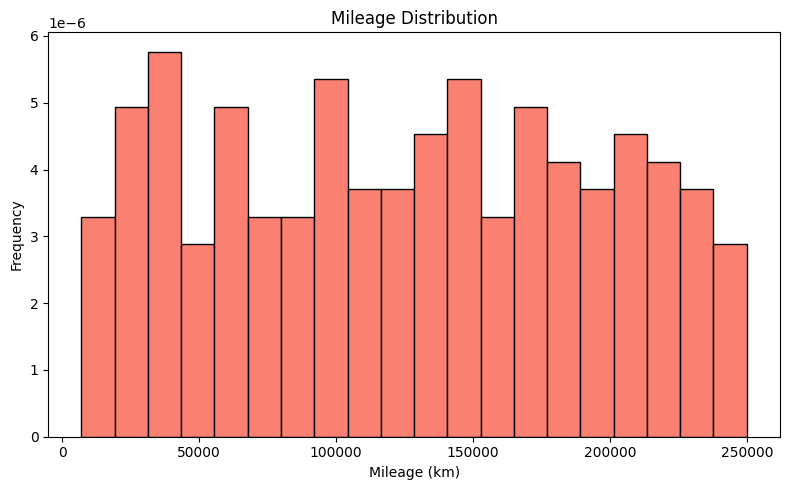

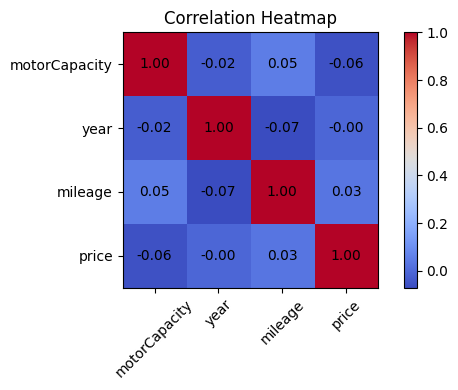

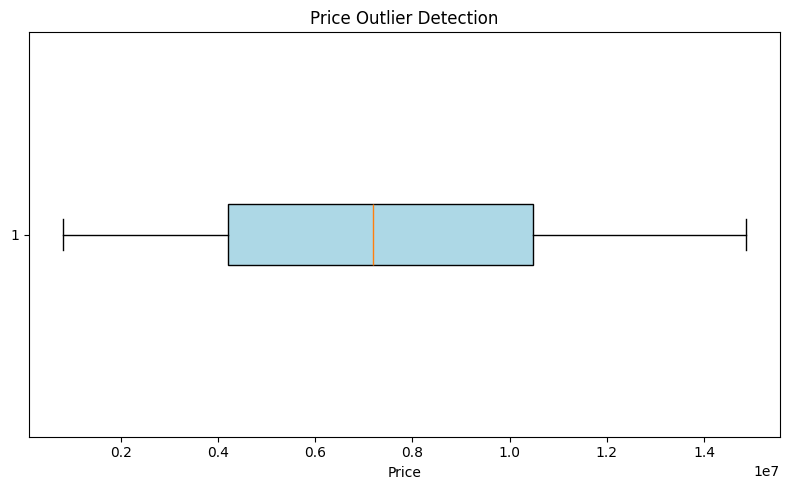

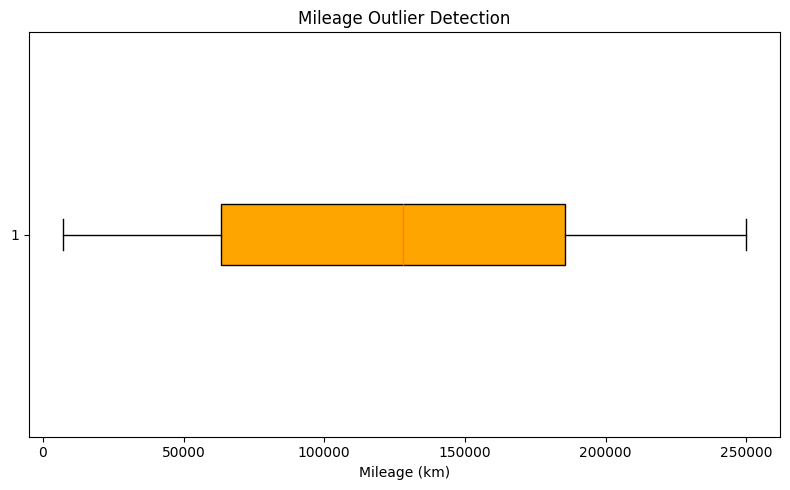

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Example synthetic dataset based on HTML form fields
np.random.seed(42)
n = 200

data = pd.DataFrame({
    "model": np.random.choice(["Toyota Camry", "Mercedes-Benz C Class", "Hyundai Elantra", "Nissan Rogue", "Kia Forte"], n),
    "type": np.random.choice(["Sedan", "SUV", "Hatchback", "Minivan"], n),
    "motorCapacity": np.random.choice([0.2, 0.3, 1.5, 1.8, 2.1, 2.2, 2.3, 2.5, 2.6, 2.8, 3.2, 3.5, 4.0, 5.0], n),
    "motorType": np.random.choice(["Petrol", "Diesel", "Gas", "Hybrid"], n),
    "color": np.random.choice(["Red", "Blue", "Black", "Silver", "Gray", "Green", "Yellow", "Orange", "Brown"], n),
    "condition": np.random.choice(["Excellent", "Good", "Fair"], n),
    "year": np.random.randint(1990, 2025, n),
    "mileage": np.random.randint(5000, 250000, n),
    "price": np.random.randint(500000, 15000000, n)  # Example currency units
})

# 1. Histogram - Price
plt.figure(figsize=(8,5))
plt.hist(data['price'], bins=20, color='skyblue', edgecolor='black', density=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 2. Histogram - Year
plt.figure(figsize=(8,5))
plt.hist(data['year'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Year of Manufacture Distribution')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 3. Histogram - Mileage
plt.figure(figsize=(8,5))
plt.hist(data['mileage'], bins=20, color='salmon', edgecolor='black', density=True)
plt.title('Mileage Distribution')
plt.xlabel('Mileage (km)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(6,4))
corr = data[['motorCapacity', 'year', 'mileage', 'price']].corr()
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# 5. Boxplot - Price Outliers
plt.figure(figsize=(8,5))
plt.boxplot(data['price'], vert=False, patch_artist=True, 
            boxprops=dict(facecolor='lightblue'))
plt.title('Price Outlier Detection')
plt.xlabel('Price')
plt.tight_layout()
plt.show()

# 6. Boxplot - Mileage Outliers
plt.figure(figsize=(8,5))
plt.boxplot(data['mileage'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='orange'))
plt.title('Mileage Outlier Detection')
plt.xlabel('Mileage (km)')
plt.tight_layout()
plt.show()

In [16]:
from xgboost import XGBRegressor


evaluation_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
evaluation_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
